## Updating the PlayerID in files

In [ ]:
import pandas as pd
import glob
import os

files = glob.glob("data_brsm/multiple/phone/*.csv")  

for file in files:
    
    df = pd.read_csv(file)
    filename = os.path.basename(file).replace(".csv","")
    player_id = filename.split("_")[0]   
    df["PlayerID"] = player_id    
    df.to_csv(file, index=False)

print("PlayerID updated successfully!")

## Combining the data files into one single files

In [ ]:
import pandas as pd
import glob

# Get all CSV files
files = glob.glob("data_brsm/single/phone/*.csv")

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

# Combine all files
combined_df = pd.concat(df_list, ignore_index=True)

# Ensure PlayerID is integer
combined_df["PlayerID"] = combined_df["PlayerID"].astype(int)

# Convert Timestamp to datetime (recommended for proper sorting)
combined_df["Timestamp"] = pd.to_datetime(combined_df["Timestamp"])

# Sort by PlayerID, then Timestamp
combined_df = combined_df.sort_values(by=["PlayerID", "Timestamp"])

# Save combined file
combined_df.to_csv("single_phone_combined.csv", index=False)

print("CSV files combined and sorted successfully!")
print("Total participants:", combined_df["PlayerID"].nunique())
print("Total rows:", combined_df.shape[0])

## Level wise mean and standard deviation calculation of reaction time

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("multiple_phone_combined.csv")

# Optional: filter unrealistic reaction times
# df = df[(df["InitialResponseTime(ms)"] > 100) & (df["InitialResponseTime(ms)"] < 2000)]

level_stats = df.groupby("Level")["InitialResponseTime(ms)"].agg(
    mean_rt="mean",
    std_rt="std",
    n="count"
).reset_index()

level_stats["se"] = level_stats["std_rt"] / np.sqrt(level_stats["n"])

level_stats.to_csv("multiple_phone_levelwise.csv", index=False)

print("Level-wise mean RT file created successfully!")
print(level_stats)

## Mean response time and Mean accuracy

In [1]:

import pandas as pd
import glob
import os
import re

folder_path = "data_brsm/single/phone/*.csv"   
files = glob.glob(folder_path)

player_data = {}

for file in files:
    
    filename = os.path.basename(file)
    player_id = int(re.search(r'\d+', filename).group())
    
    df = pd.read_csv(file)
    
    # Ignore rows where RT = 0
    df_rt = df[df["InitialResponseTime(ms)"] > 0]
    
    mean_rt_file = None
    if not df_rt.empty:
        mean_rt_file = df_rt["InitialResponseTime(ms)"].mean()
    
    level_accuracy = df.groupby("Level")["HitRate(%)"].mean()
    overall_accuracy_file = level_accuracy.mean()
    
    if player_id not in player_data:
        player_data[player_id] = {
            "rt_list": [],
            "acc_list": []
        }
    
    if mean_rt_file is not None:
        player_data[player_id]["rt_list"].append(mean_rt_file)
    
    player_data[player_id]["acc_list"].append(overall_accuracy_file)


final_results = []

for player_id, values in player_data.items():
    
    final_mean_rt = (
        sum(values["rt_list"]) / len(values["rt_list"])
        if values["rt_list"] else None
    )
    
    final_mean_acc = sum(values["acc_list"]) / len(values["acc_list"])
    
    final_results.append({
        "PlayerID": player_id,
        "Mean_Response_Time(ms)": final_mean_rt,
        "Mean_Accuracy(%)": final_mean_acc
    })

results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values("PlayerID").reset_index(drop=True)
results_df.to_csv("Final_Player_Summary.csv", index=False)

print("Final CSV Created Successfully and Sorted!")
print(results_df)

Final CSV Created Successfully and Sorted!
    PlayerID  Mean_Response_Time(ms)  Mean_Accuracy(%)
0          1             3107.333333        100.000000
1          2             3977.733333         96.666667
2          3             2439.533333         96.666667
3          4             3026.733333         96.666667
4          5             4682.600000         88.888889
5          6             3091.235294         93.333333
6          7             3064.466667        100.000000
7          8             2922.666667         92.222222
8          9             2686.200000        100.000000
9         10             2967.600000        100.000000
10        11             2604.333333        100.000000
11        12             2649.333333        100.000000
12        13             2900.133333        100.000000
13        14             3793.866667        100.000000
14        15             2257.933333         96.666667
15        16             2696.933333        100.000000
16        17          

## Mean, Median and Standard Deviation of the Reaction times for single target

In [ ]:
import pandas as pd
import glob
import os
import re
import numpy as np

folder_path = "data_brsm/single/phone/*.csv" 
files = glob.glob(folder_path)

player_data = {}

for file in files:
    
    filename = os.path.basename(file)
    player_id = int(re.search(r'\d+', filename).group())
    
    df = pd.read_csv(file)
    
    # 🔹 REACTION TIME
    # Ignore rows where RT = 0
    df_rt = df[df["InitialResponseTime(ms)"] > 0]
    
    rt_values = df_rt["InitialResponseTime(ms)"].tolist()
    
    if player_id not in player_data:
        player_data[player_id] = {
            "all_rts": []  # store all RTs for mean, median, std
        }
    
    player_data[player_id]["all_rts"].extend(rt_values)


final_results = []

for player_id, values in player_data.items():
    
    rts = values["all_rts"]
    
    if rts:
        median_rt = np.median(rts)
        mean_rt = np.mean(rts)
        std_rt = np.std(rts, ddof=1)  
    else:
        median_rt = mean_rt = std_rt = None
    
    final_results.append({
        "PlayerID": player_id,
        "Median_Response_Time(ms)": median_rt,
        "Mean_Response_Time(ms)": mean_rt,
        "StdDev_Response_Time(ms)": std_rt
    })

results_df = pd.DataFrame(final_results)

results_df = results_df.sort_values("PlayerID").reset_index(drop=True)

results_df.to_csv("single_phone_mmsd.csv", index=False)

print("Final CSV Created Successfully and Sorted!")
print(results_df)

Final CSV Created Successfully and Sorted!
    PlayerID  Median_Response_Time(ms)  Mean_Response_Time(ms)  \
0          1                    2749.0             3107.333333   
1          2                    2533.0             3977.733333   
2          3                    1920.0             2439.533333   
3          4                    2417.0             3026.733333   
4          5                    3113.0             4682.600000   
5          6                    2504.0             3091.235294   
6          7                    2085.0             3064.466667   
7          8                    2120.0             2922.666667   
8          9                    2451.0             2686.200000   
9         10                    2069.0             2967.600000   
10        11                    1685.0             2604.333333   
11        12                    1608.0             2649.333333   
12        13                    2114.0             2900.133333   
13        14                    1

## Mean, Median and Standard Deviation of the Reaction times for multiple targets

In [85]:
import pandas as pd
import glob
import os
import re
import numpy as np

# ---- STEP 1: Set folder path ----
folder_path = "data_brsm/multiple/phone/*.csv"   # <<< CHANGE THIS
files = glob.glob(folder_path)

player_data = {}

for file in files:
    
    # ---- STEP 2: Extract numeric PlayerID from filename ----
    filename = os.path.basename(file)
    player_id = int(re.search(r'\d+', filename).group())
    
    # ---- STEP 3: Read CSV ----
    df = pd.read_csv(file)
    
    # ----------------------------
    # 🔹 REACTION TIME
    # Ignore rows where RT = 0
    # ----------------------------
    df_rt = df[df["InitialResponseTime(ms)"] > 0]
    
    rt_values = df_rt["InitialResponseTime(ms)"].tolist()
    
    # ---- Store data per player ----
    if player_id not in player_data:
        player_data[player_id] = {
            "all_rts": []  # store all RTs for mean, median, std
        }
    
    player_data[player_id]["all_rts"].extend(rt_values)


# ---- STEP 4: Create final summary (ONE ROW PER PLAYER) ----
final_results = []

for player_id, values in player_data.items():
    
    rts = values["all_rts"]
    
    if rts:
        median_rt = np.median(rts)
        mean_rt = np.mean(rts)
        std_rt = np.std(rts, ddof=1)  # sample standard deviation
    else:
        median_rt = mean_rt = std_rt = None
    
    final_results.append({
        "PlayerID": player_id,
        "Median_Response_Time(ms)": median_rt,
        "Mean_Response_Time(ms)": mean_rt,
        "StdDev_Response_Time(ms)": std_rt
    })

# ---- STEP 5: Convert to DataFrame ----
results_df = pd.DataFrame(final_results)

# ---- STEP 6: Sort numerically by PlayerID ----
results_df = results_df.sort_values("PlayerID").reset_index(drop=True)

# ---- STEP 7: Save CSV ----
results_df.to_csv("multiple_phone_mmsd.csv", index=False)

print("Final CSV Created Successfully and Sorted!")
print(results_df)

Final CSV Created Successfully and Sorted!
    PlayerID  Median_Response_Time(ms)  Mean_Response_Time(ms)  \
0         22                    1329.5             1531.333333   
1         23                    1602.5             1969.416667   
2         24                    2084.0             3120.416667   
3         25                    1084.5             1176.700000   
4         26                    1536.0             2160.727273   
5         27                    1992.0             2547.727273   
6         28                    1363.0             1704.090909   
7         29                    1515.0             1746.090909   
8         30                    1308.5             1400.800000   
9         31                    1479.0             1490.000000   
10        32                    1461.5             1700.083333   
11        33                    1550.0             1692.181818   
12        34                    1617.0             2219.300000   
13        35                    1

In [5]:
import pandas as pd

df = pd.read_csv("Single_Phone_Final_Stats.csv")
print(df.columns)

Index(['participant', 'target_load', 'modality', 'RT_mean(ms)',
       'Accuracy_mean', 'Initial_RT'],
      dtype='object')


## Mean Reaction Time and Accuracy

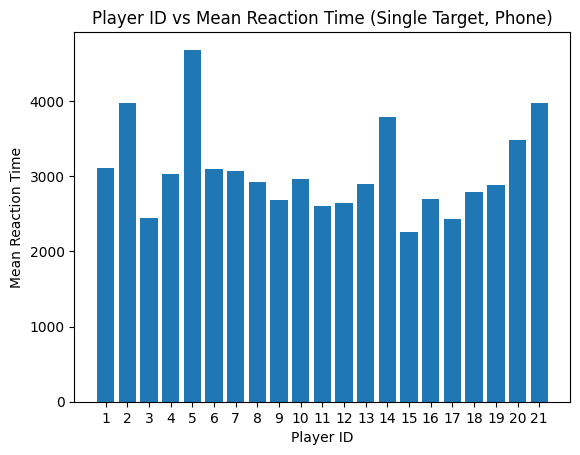

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read CSV file
df = pd.read_csv("Single_Phone_Final_Stats.csv")

# Sort by PlayerID
df = df.sort_values("participant")

# Extract values
x = df["participant"]
y = df["RT_mean(ms)"]

# Create bar plot
plt.figure()
plt.bar(x, y)

# Set x-axis ticks with gap of 1
plt.xticks(np.arange(min(x), max(x) + 1, 1))

plt.xlabel("Player ID")
plt.ylabel("Mean Reaction Time")
plt.title("Player ID vs Mean Reaction Time (Single Target, Phone)")

plt.show()

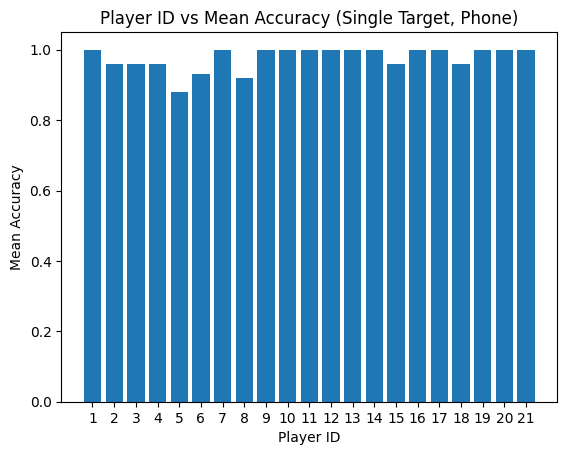

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Single_Phone_Final_Stats.csv")
df = df.sort_values("participant")

x = df["participant"]
y = df["Accuracy_mean"]

plt.figure()
plt.bar(x, y)

plt.xticks(np.arange(min(x), max(x) + 1, 1))

plt.xlabel("Player ID")
plt.ylabel("Mean Accuracy")
plt.title("Player ID vs Mean Accuracy (Single Target, Phone)")

plt.show()

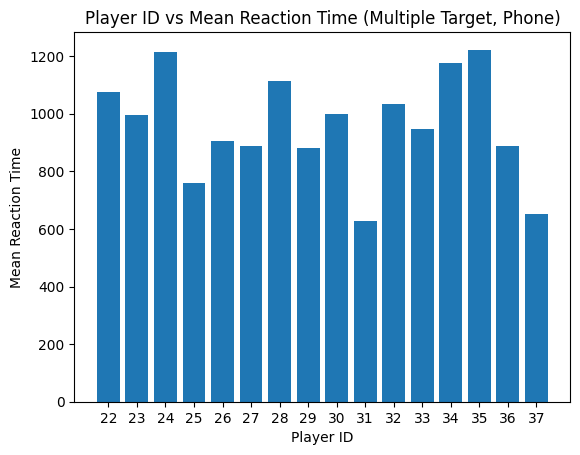

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("multiple_summary_phone.csv")
df = df.sort_values("participant")

x = df["participant"]
y = df["RT_mean(ms)"]

plt.figure()
plt.bar(x, y)

plt.xticks(np.arange(min(x), max(x) + 1, 1))

plt.xlabel("Player ID")
plt.ylabel("Mean Reaction Time")
plt.title("Player ID vs Mean Reaction Time (Multiple Target, Phone)")

plt.show()

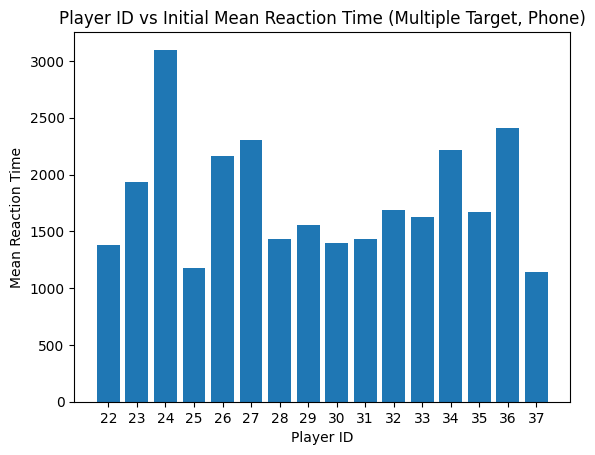

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("multiple_summary_phone.csv")
df = df.sort_values("participant")

x = df["participant"]
y = df["Initial_RT(ms)"]

plt.figure()
plt.bar(x, y)

plt.xticks(np.arange(min(x), max(x) + 1, 1))

plt.xlabel("Player ID")
plt.ylabel("Mean Reaction Time")
plt.title("Player ID vs Initial Mean Reaction Time (Multiple Target, Phone)")

plt.show()

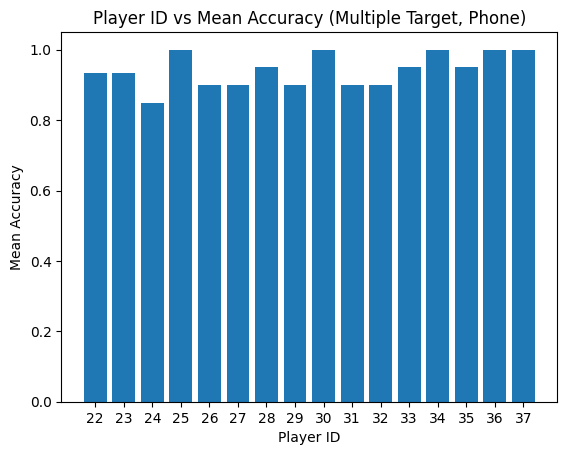

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("multiple_summary_phone.csv")

df = df.sort_values("participant")

x = df["participant"]
y = df["Accuracy_mean"]

plt.figure()
plt.bar(x, y)

plt.xticks(np.arange(min(x), max(x) + 1, 1))

plt.xlabel("Player ID")
plt.ylabel("Mean Accuracy")
plt.title("Player ID vs Mean Accuracy (Multiple Target, Phone)")

plt.show()

In [19]:
import pandas as pd
from scipy.stats import shapiro

df = pd.read_csv("Combined.csv")
df.columns = df.columns.str.strip()

def normality_check(condition, variable):

    subset = df[df["target_load"] == condition]

    pivot = subset.pivot(index="participant",
                         columns="modality",
                         values=variable)

    pivot = pivot.dropna()

    # Compute difference
    diff = pivot["Lab"] - pivot["Phone"]

    stat, p = shapiro(diff)

    print(f"\nNormality Check: {condition} - {variable}")
    print("Shapiro-Wilk p-value =", round(p, 4))

    if p > 0.05:
        print("→ Differences are normally distributed ✔")
    else:
        print("→ Differences are NOT normally distributed ✖")


# Run checks
normality_check("Single", "RT_mean(ms)")
normality_check("Multiple", "RT_mean(ms)")
normality_check("Single", "Accuracy_mean")
normality_check("Multiple", "Accuracy_mean")


Normality Check: Single - RT_mean(ms)
Shapiro-Wilk p-value = 0.0723
→ Differences are normally distributed ✔

Normality Check: Multiple - RT_mean(ms)
Shapiro-Wilk p-value = 0.0004
→ Differences are NOT normally distributed ✖

Normality Check: Single - Accuracy_mean
Shapiro-Wilk p-value = 0.0
→ Differences are NOT normally distributed ✖

Normality Check: Multiple - Accuracy_mean
Shapiro-Wilk p-value = 0.0395
→ Differences are NOT normally distributed ✖


## SINGLE Vs MULTIPLE



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Combined.csv")

print(df.head())
print(df.describe())

   participant  Initial_RT(ms)  RT_mean(ms)  Accuracy_mean modality  \
0           22     1381.700000  1075.400000       0.933333    Phone   
1           37     1138.500000   652.200000       1.000000    Phone   
2           35     1668.200000  1222.100000       0.950000    Phone   
3           32     1684.300000  1032.600000       0.900000    Phone   
4           29     1555.111111   880.333333       0.900000    Phone   

  target_load  
0    Multiple  
1    Multiple  
2    Multiple  
3    Multiple  
4    Multiple  
       participant  Initial_RT(ms)  RT_mean(ms)  Accuracy_mean
count     74.00000       74.000000    74.000000      74.000000
mean      19.00000     2043.770346  1808.864277       0.981036
std       10.74996      784.624024   900.234132       0.036259
min        1.00000     1138.500000   628.666667       0.850000
25%       10.00000     1471.026953  1215.918629       0.970000
50%       19.00000     1659.087590  1463.663137       1.000000
75%       28.00000     2563.133333  

In [2]:
phone_data = df[df["modality"] == "Phone"]
lab_data = df[df["modality"] == "Lab"]


### Reaction Time

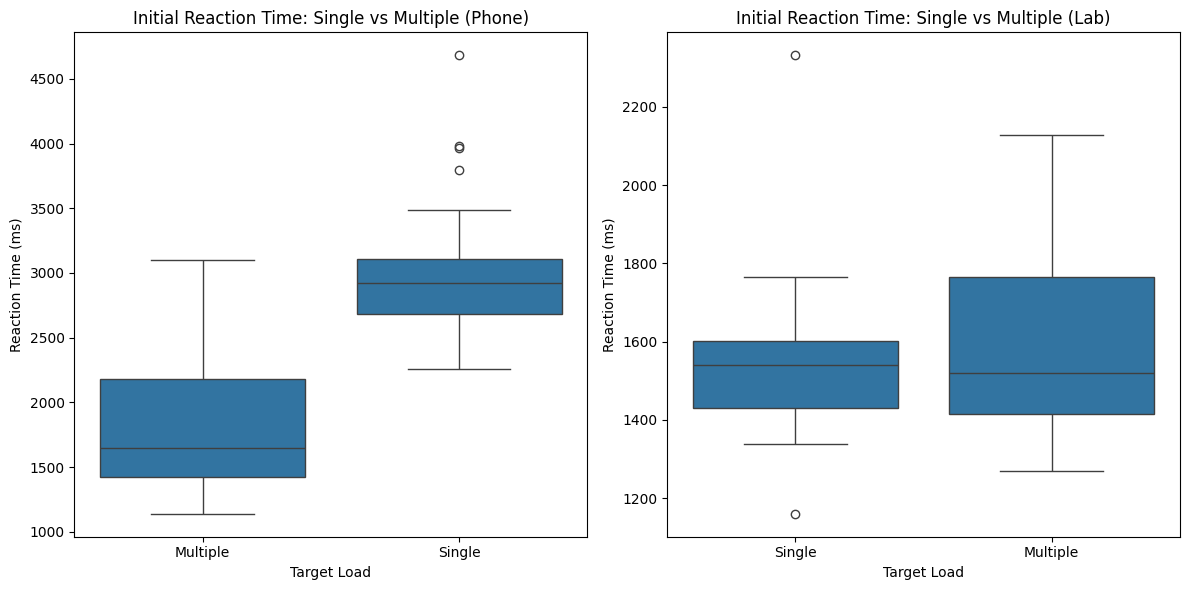

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---- Phone condition ----
sns.boxplot(
    x="target_load",
    y="Initial_RT(ms)",
    data=phone_data,
    ax=axes[0]
)

axes[0].set_title("Initial Reaction Time: Single vs Multiple (Phone)")
axes[0].set_xlabel("Target Load")
axes[0].set_ylabel("Reaction Time (ms)")

# ---- Lab condition ----
sns.boxplot(
    x="target_load",
    y="Initial_RT(ms)",
    data=lab_data,
    ax=axes[1]
)

axes[1].set_title("Initial Reaction Time: Single vs Multiple (Lab)")
axes[1].set_xlabel("Target Load")
axes[1].set_ylabel("Reaction Time (ms)")

# Adjust layout
plt.tight_layout()

plt.show()

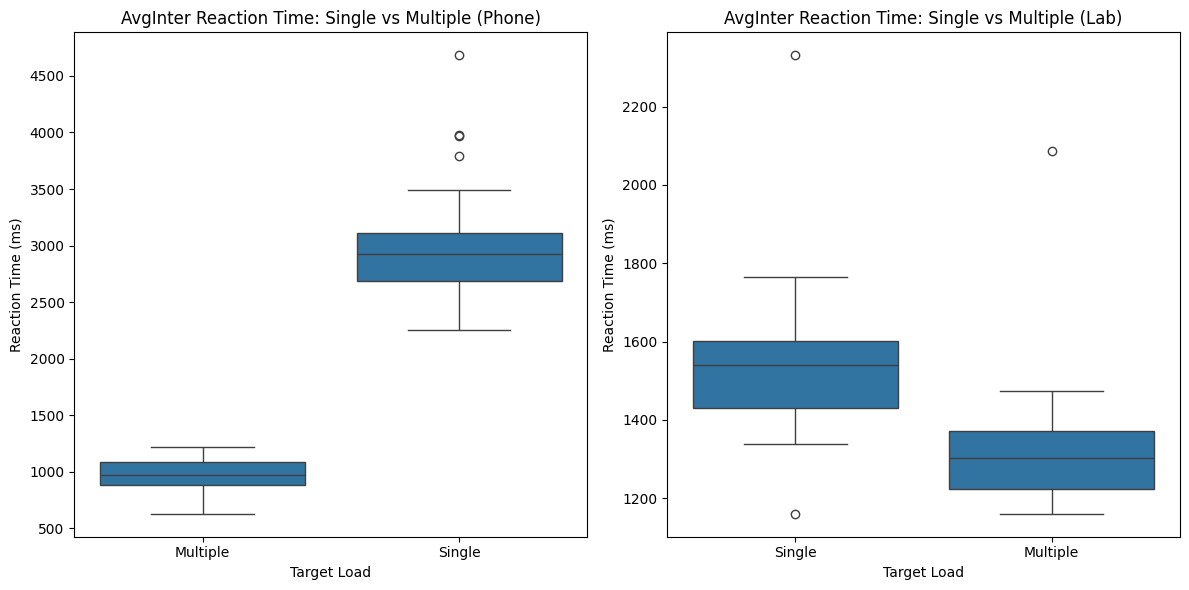

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---- Phone condition ----
sns.boxplot(
    x="target_load",
    y="RT_mean(ms)",
    data=phone_data,
    ax=axes[0]
)

axes[0].set_title("AvgInter Reaction Time: Single vs Multiple (Phone)")
axes[0].set_xlabel("Target Load")
axes[0].set_ylabel("Reaction Time (ms)")

# ---- Lab condition ----
sns.boxplot(
    x="target_load",
    y="RT_mean(ms)",
    data=lab_data,
    ax=axes[1]
)

axes[1].set_title("AvgInter Reaction Time: Single vs Multiple (Lab)")
axes[1].set_xlabel("Target Load")
axes[1].set_ylabel("Reaction Time (ms)")

# Adjust layout
plt.tight_layout()

plt.show()

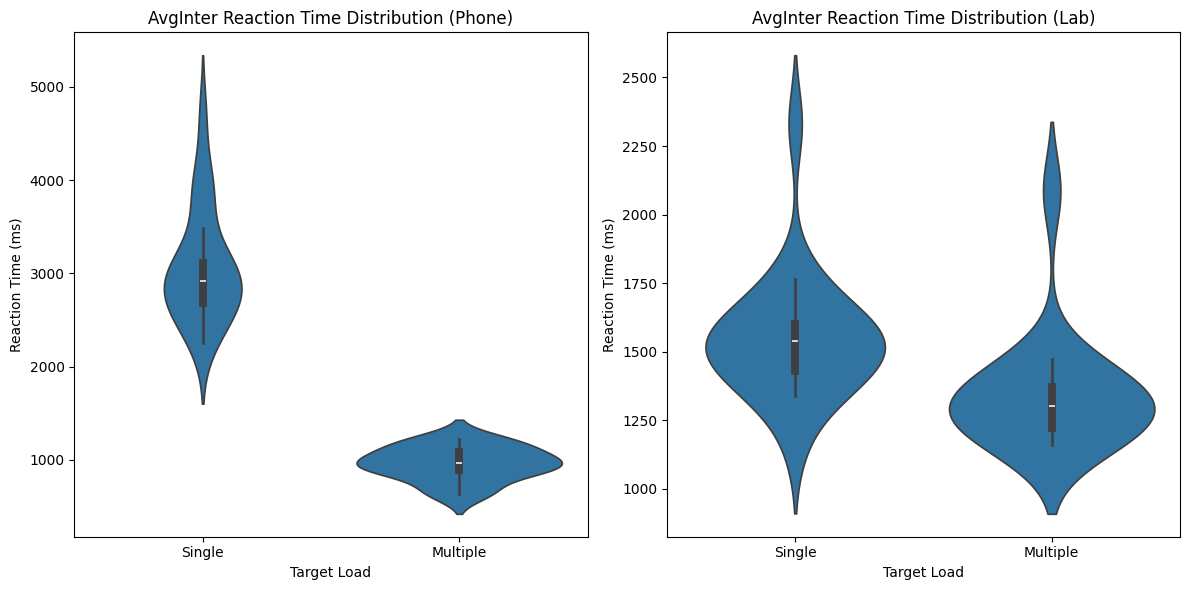

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---- Phone condition ----
sns.violinplot(
    x="target_load",
    y="RT_mean(ms)",
    data=phone_data,
    order=["Single", "Multiple"],
    ax=axes[0]
)

axes[0].set_title("AvgInter Reaction Time Distribution (Phone)")
axes[0].set_xlabel("Target Load")
axes[0].set_ylabel("Reaction Time (ms)")

# ---- Lab condition ----
sns.violinplot(
    x="target_load",
    y="RT_mean(ms)",
    data=lab_data,
    order=["Single", "Multiple"],
    ax=axes[1]
)

axes[1].set_title("AvgInter Reaction Time Distribution (Lab)")
axes[1].set_xlabel("Target Load")
axes[1].set_ylabel("Reaction Time (ms)")

# Adjust layout
plt.tight_layout()

plt.show()

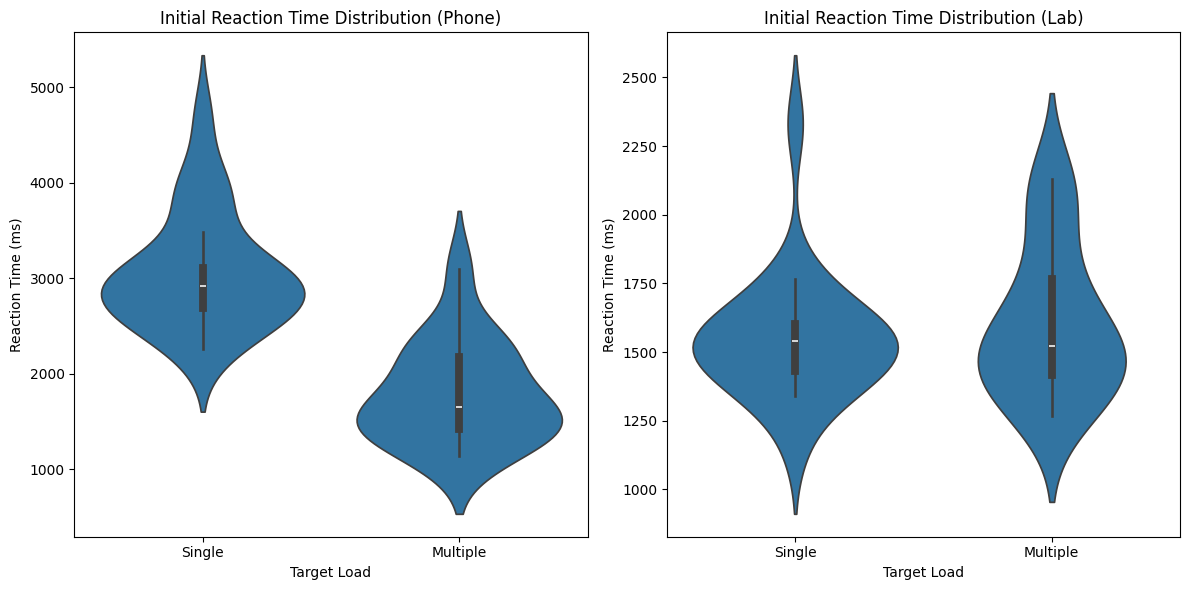

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---- Phone condition ----
sns.violinplot(
    x="target_load",
    y="Initial_RT(ms)",
    data=phone_data,
    order=["Single", "Multiple"],
    ax=axes[0]
)

axes[0].set_title("Initial Reaction Time Distribution (Phone)")
axes[0].set_xlabel("Target Load")
axes[0].set_ylabel("Reaction Time (ms)")

# ---- Lab condition ----
sns.violinplot(
    x="target_load",
    y="Initial_RT(ms)",
    data=lab_data,
    order=["Single", "Multiple"],
    ax=axes[1]
)

axes[1].set_title("Initial Reaction Time Distribution (Lab)")
axes[1].set_xlabel("Target Load")
axes[1].set_ylabel("Reaction Time (ms)")

# Adjust layout
plt.tight_layout()

plt.show()

## Distributions

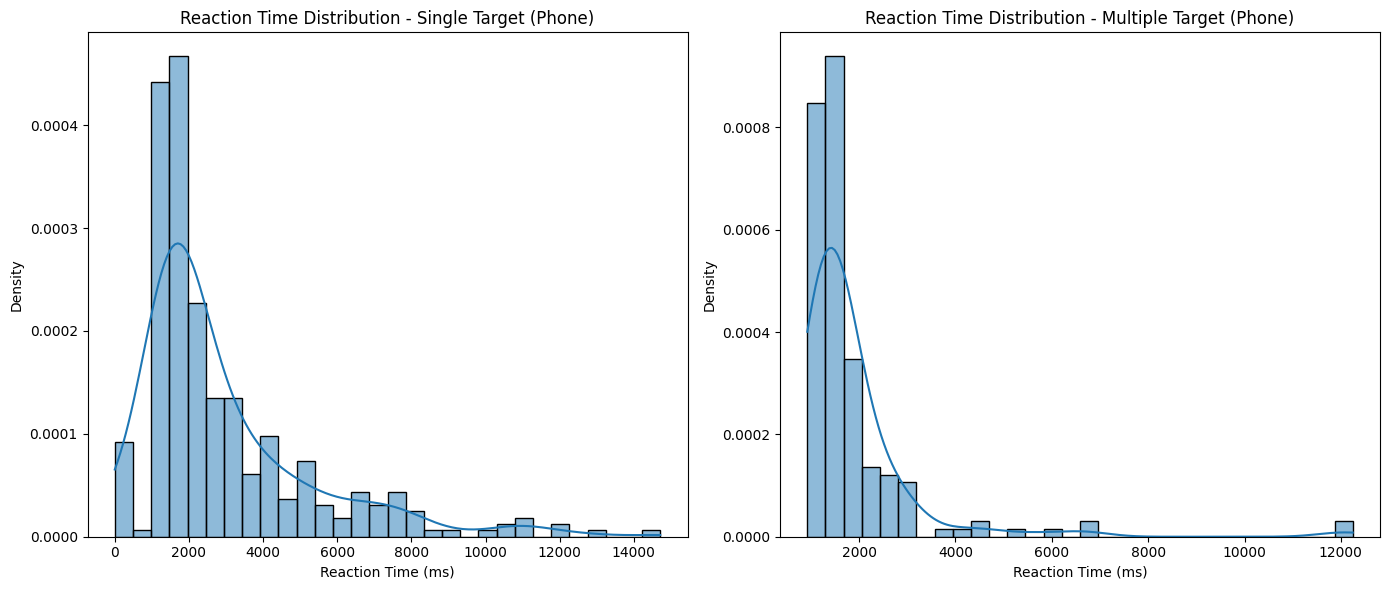

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
single_df = pd.read_csv("single_phone_combined.csv")
multiple_df = pd.read_csv("multiple_phone_combined.csv")

# Filter conditions
single_phone = single_df[single_df["GameMode"] == "singleTarget"]
multiple_phone = multiple_df[multiple_df["GameMode"] == "multipleTargets"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(
    data=single_phone,
    x="InitialResponseTime(ms)",
    bins=30,
    stat="density",
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Reaction Time Distribution - Single Target (Phone)")
axes[0].set_xlabel("Reaction Time (ms)")
axes[0].set_ylabel("Density")

sns.histplot(
    data=multiple_phone,
    x="InitialResponseTime(ms)",
    bins=30,
    stat="density",
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Reaction Time Distribution - Multiple Target (Phone)")
axes[1].set_xlabel("Reaction Time (ms)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

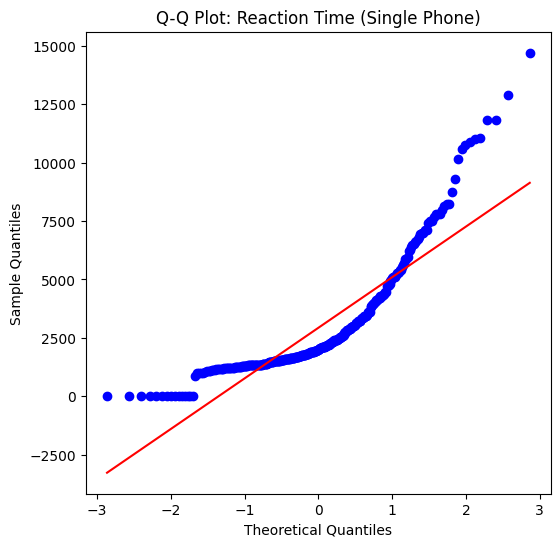

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("single_phone_combined.csv")

single_phone = df[
    (df["GameMode"] == "singleTarget") 
]

rt = single_phone["InitialResponseTime(ms)"]

plt.figure(figsize=(6,6))
stats.probplot(rt, dist="norm", plot=plt)

plt.title("Q-Q Plot: Reaction Time (Single Phone)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

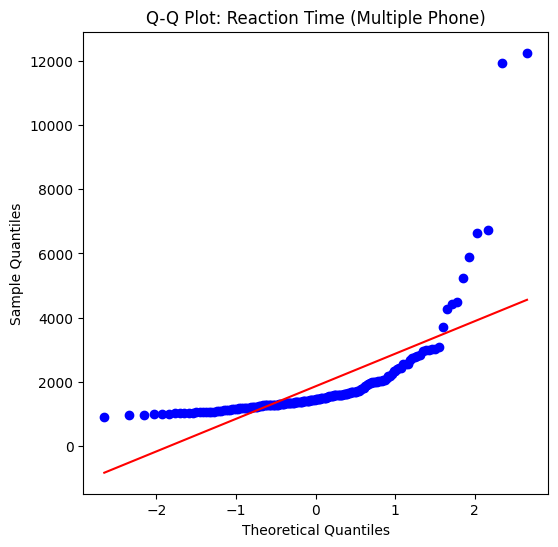

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("multiple_phone_combined.csv")

single_phone = df[
    (df["GameMode"] == "multipleTargets") 
]

rt = single_phone["InitialResponseTime(ms)"]

plt.figure(figsize=(6,6))
stats.probplot(rt, dist="norm", plot=plt)

plt.title("Q-Q Plot: Reaction Time (Multiple Phone)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

## Level wise Analysis

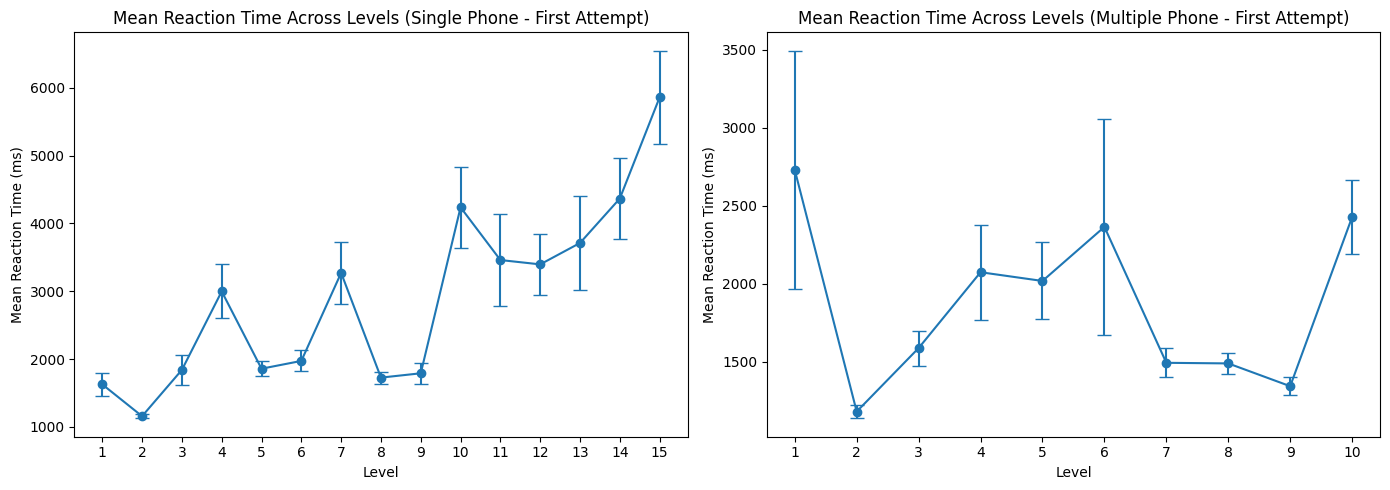

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

single_stats = pd.read_csv("single_phone_levelwise_first_attempt.csv")
multiple_stats = pd.read_csv("multiple_phone_levelwise_first_attempt.csv")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].errorbar(
    single_stats["Level"],
    single_stats["mean_rt"],
    yerr=single_stats["se"],
    fmt='-o',
    capsize=5
)

axes[0].set_title("Mean Reaction Time Across Levels (Single Phone - First Attempt)")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Mean Reaction Time (ms)")
axes[0].set_xticks(single_stats["Level"])

# ---- Multiple Target Plot ----
axes[1].errorbar(
    multiple_stats["Level"],
    multiple_stats["mean_rt"],
    yerr=multiple_stats["se"],
    fmt='-o',
    capsize=5
)

axes[1].set_title("Mean Reaction Time Across Levels (Multiple Phone - First Attempt)")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Mean Reaction Time (ms)")
axes[1].set_xticks(multiple_stats["Level"])

plt.tight_layout()
plt.show()

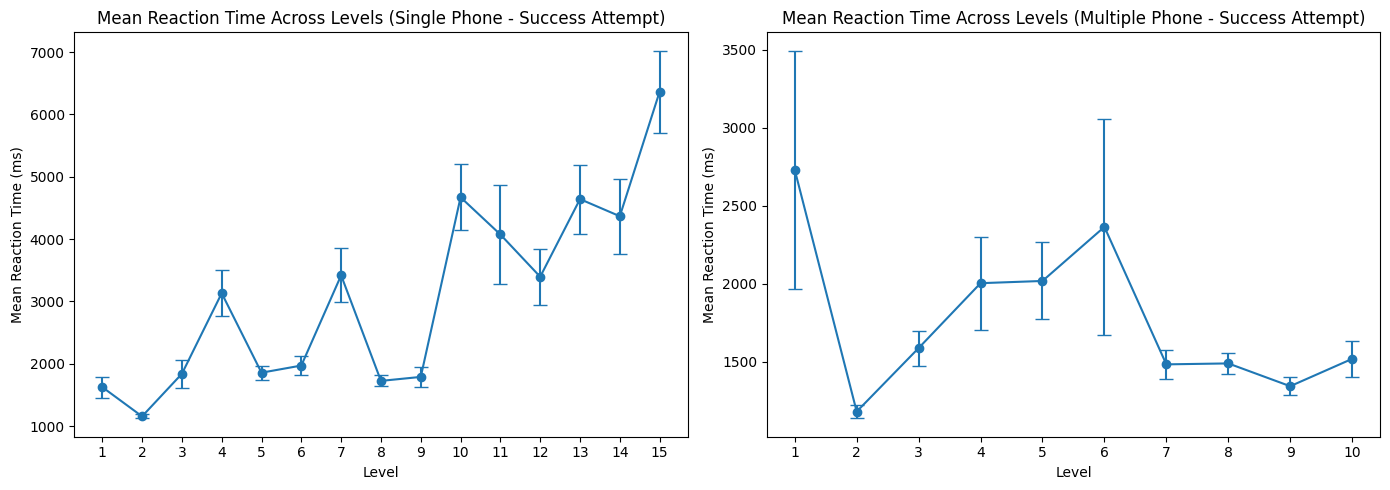

In [130]:

import pandas as pd
import matplotlib.pyplot as plt

single_stats = pd.read_csv("single_phone_levelwise_success_attempt.csv")
multiple_stats = pd.read_csv("multiple_phone_levelwise_success_attempt.csv")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].errorbar(
    single_stats["Level"],
    single_stats["mean_rt"],
    yerr=single_stats["se"],
    fmt='-o',
    capsize=5
)

axes[0].set_title("Mean Reaction Time Across Levels (Single Phone - Success Attempt)")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Mean Reaction Time (ms)")
axes[0].set_xticks(single_stats["Level"])

axes[1].errorbar(
    multiple_stats["Level"],
    multiple_stats["mean_rt"],
    yerr=multiple_stats["se"],
    fmt='-o',
    capsize=5
)

axes[1].set_title("Mean Reaction Time Across Levels (Multiple Phone - Success Attempt)")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Mean Reaction Time (ms)")
axes[1].set_xticks(multiple_stats["Level"])

plt.tight_layout()
plt.show()

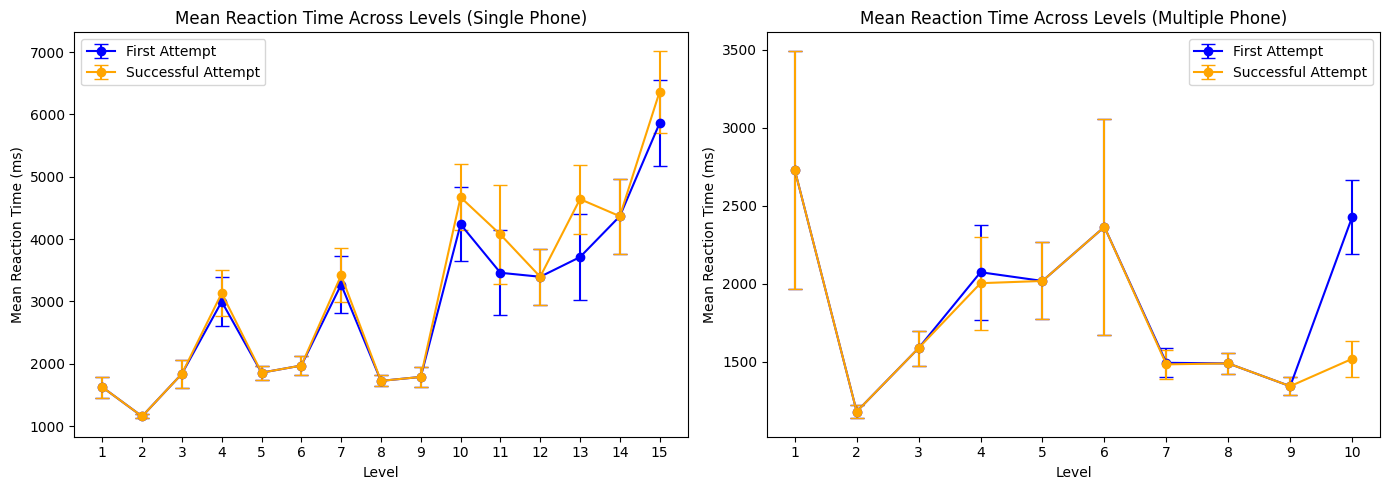

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

single_first = pd.read_csv("single_phone_levelwise_first_attempt.csv")
single_success = pd.read_csv("single_phone_levelwise_success_attempt.csv")

multiple_first = pd.read_csv("multiple_phone_levelwise_first_attempt.csv")
multiple_success = pd.read_csv("multiple_phone_levelwise_success_attempt.csv")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].errorbar(
    single_first["Level"],
    single_first["mean_rt"],
    yerr=single_first["se"],
    fmt='-o',
    capsize=5,
    label="First Attempt",
    color="blue"
)

axes[0].errorbar(
    single_success["Level"],
    single_success["mean_rt"],
    yerr=single_success["se"],
    fmt='-o',
    capsize=5,
    label="Successful Attempt",
    color="orange"
)

axes[0].set_title("Mean Reaction Time Across Levels (Single Phone)")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Mean Reaction Time (ms)")
axes[0].set_xticks(single_first["Level"])
axes[0].legend()


axes[1].errorbar(
    multiple_first["Level"],
    multiple_first["mean_rt"],
    yerr=multiple_first["se"],
    fmt='-o',
    capsize=5,
    label="First Attempt",
    color="blue"
)

axes[1].errorbar(
    multiple_success["Level"],
    multiple_success["mean_rt"],
    yerr=multiple_success["se"],
    fmt='-o',
    capsize=5,
    label="Successful Attempt",
    color="orange"
)

axes[1].set_title("Mean Reaction Time Across Levels (Multiple Phone)")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Mean Reaction Time (ms)")
axes[1].set_xticks(multiple_first["Level"])
axes[1].legend()

plt.tight_layout()
plt.show()

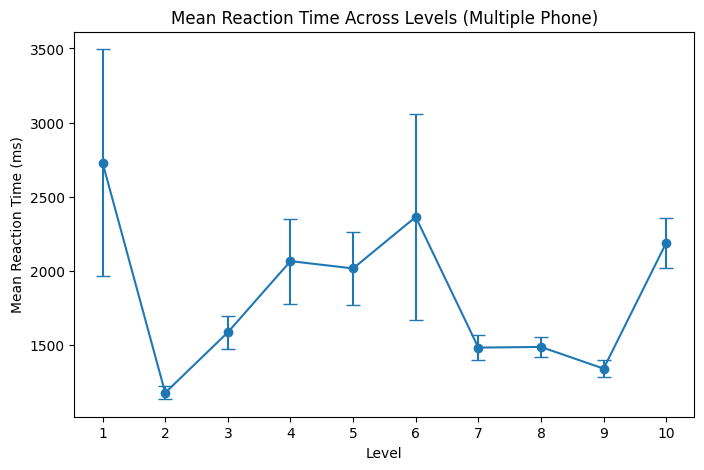

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

level_stats_multiple = pd.read_csv("multiple_phone_levelwise.csv")

plt.figure(figsize=(8,5))
plt.errorbar(
    level_stats_multiple["Level"],
    level_stats_multiple["mean_rt"],
    yerr=level_stats_multiple["se"],   
    fmt='-o',
    capsize=5
)
plt.title("Mean Reaction Time Across Levels (Multiple Phone)")
plt.xlabel("Level")
plt.ylabel("Mean Reaction Time (ms)")
plt.xticks(level_stats_multiple["Level"])
plt.show()

   Level  false_alarms  total_trials  false_alarm_rate
0      1             2            16          0.125000
1      2             0            16          0.000000
2      3             1            16          0.062500
3      4             8            17          0.470588
4      5             1            16          0.062500
5      6            11            16          0.687500
6      7            11            17          0.647059
7      8             6            16          0.375000
8      9             1            16          0.062500
9     10            33            29          1.137931


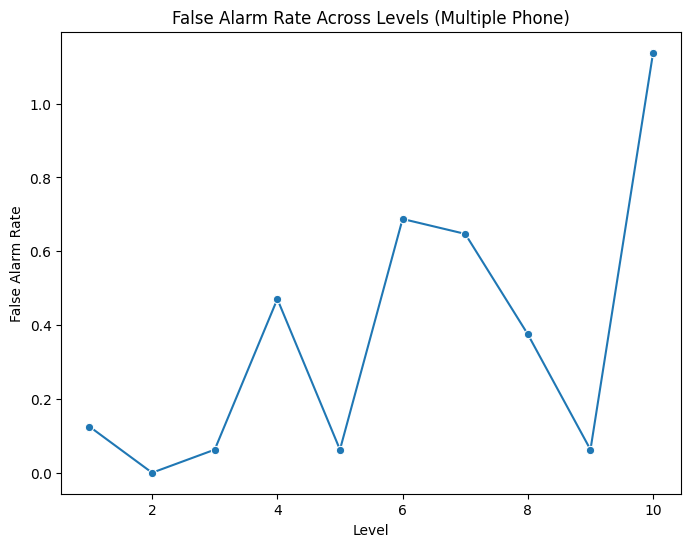

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("multiple_phone_combined.csv")

fa_stats = df.groupby("Level").agg(
    false_alarms=("FalseAlarms", "sum"),
    total_trials=("FalseAlarms", "count")
).reset_index()

fa_stats["false_alarm_rate"] = fa_stats["false_alarms"] / fa_stats["total_trials"]

print(fa_stats)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.lineplot(
    data=fa_stats,
    x="Level",
    y="false_alarm_rate",
    marker="o"
)

plt.title("False Alarm Rate Across Levels (Multiple Phone)")
plt.xlabel("Level")
plt.ylabel("False Alarm Rate")

plt.show()

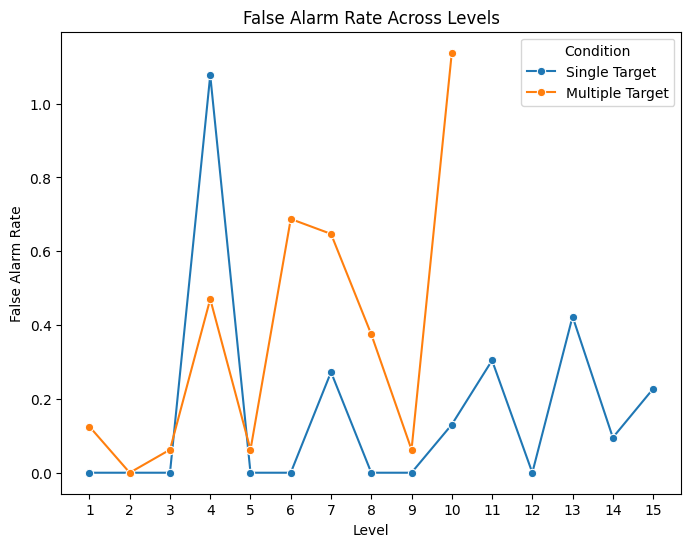

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_single = pd.read_csv("single_phone_combined.csv")
df_multiple = pd.read_csv("multiple_phone_combined.csv")

fa_single = df_single.groupby("Level").agg(
    false_alarms=("FalseAlarms", "sum"),
    total_trials=("FalseAlarms", "count")
).reset_index()

fa_single["false_alarm_rate"] = fa_single["false_alarms"] / fa_single["total_trials"]
fa_single["Condition"] = "Single Target"

fa_multiple = df_multiple.groupby("Level").agg(
    false_alarms=("FalseAlarms", "sum"),
    total_trials=("FalseAlarms", "count")
).reset_index()

fa_multiple["false_alarm_rate"] = fa_multiple["false_alarms"] / fa_multiple["total_trials"]
fa_multiple["Condition"] = "Multiple Target"

fa_combined = pd.concat([fa_single, fa_multiple])

plt.figure(figsize=(8,6))

sns.lineplot(
    data=fa_combined,
    x="Level",
    y="false_alarm_rate",
    hue="Condition",
    marker="o"
)

plt.xticks(sorted(fa_combined["Level"].unique()))

plt.title("False Alarm Rate Across Levels")
plt.xlabel("Level")
plt.ylabel("False Alarm Rate")

plt.show()

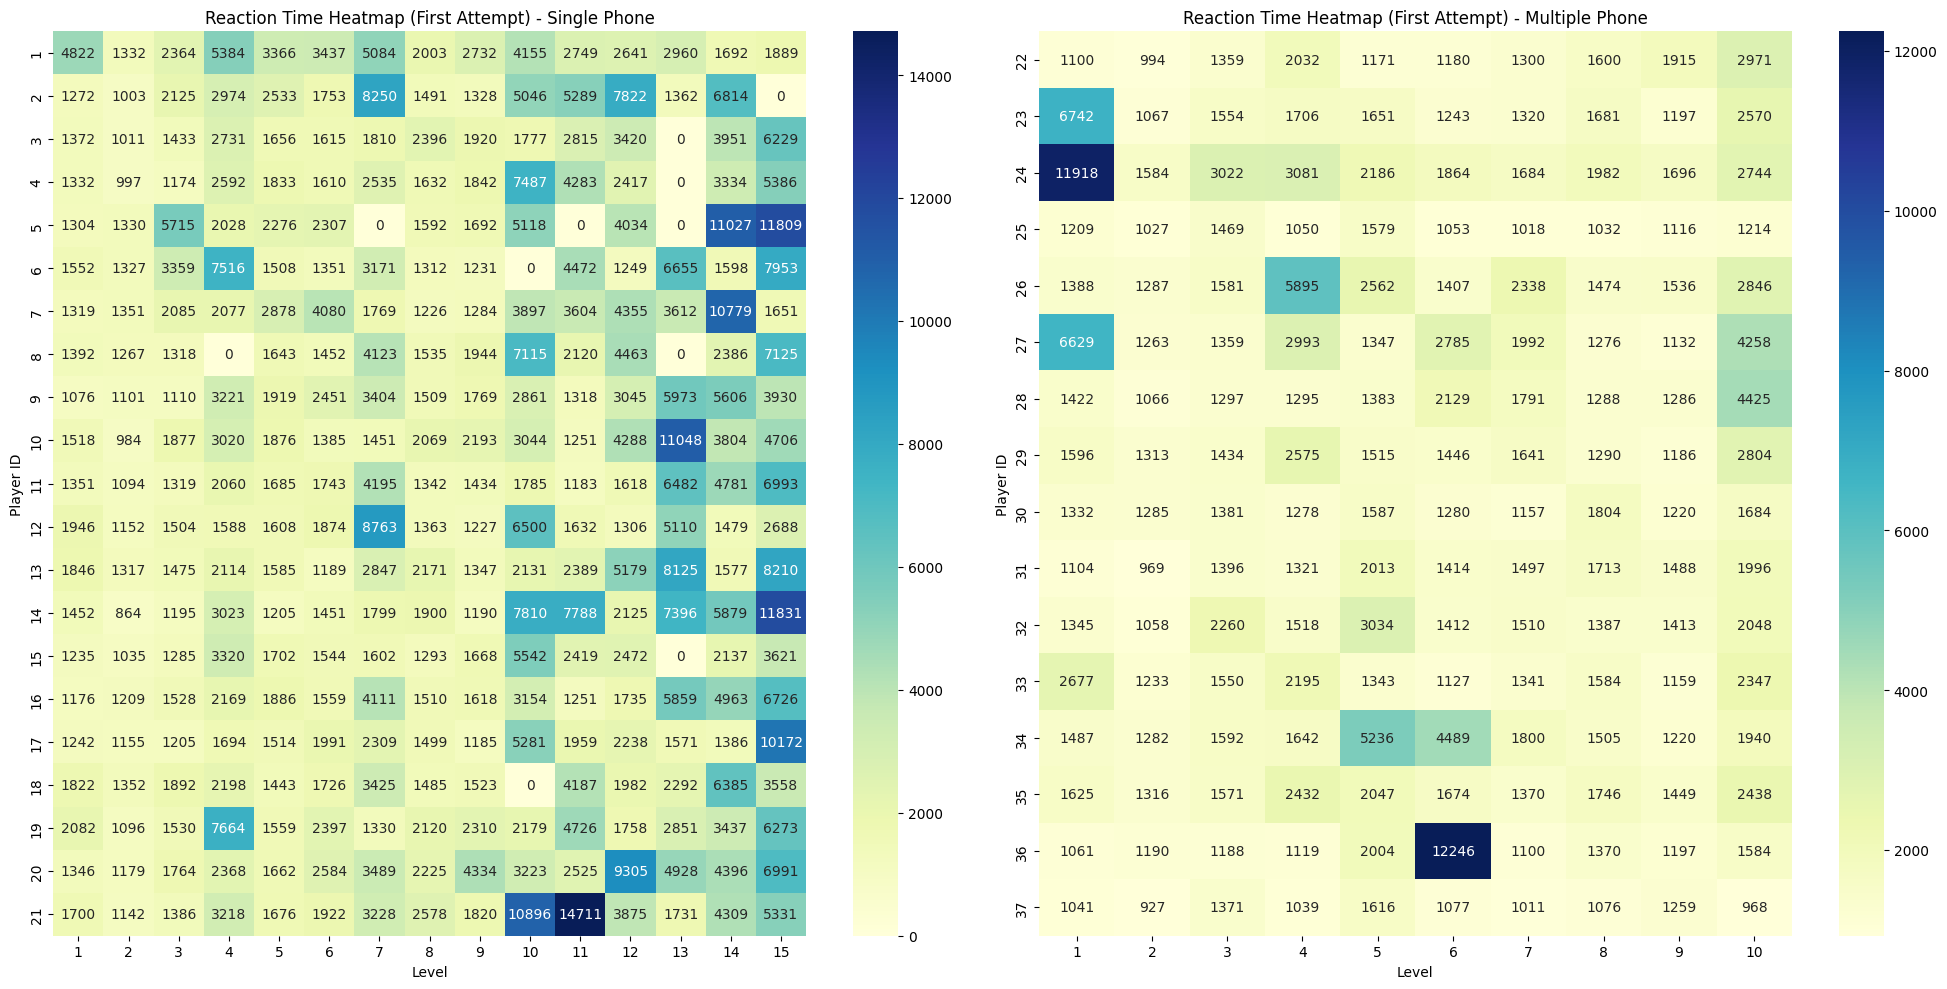

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_single = pd.read_csv("single_phone_combined.csv")
df_multiple = pd.read_csv("multiple_phone_combined.csv")

df_single["Timestamp"] = pd.to_datetime(df_single["Timestamp"])
df_multiple["Timestamp"] = pd.to_datetime(df_multiple["Timestamp"])

df_single = df_single.sort_values(by=["PlayerID", "Level", "Timestamp"])
df_multiple = df_multiple.sort_values(by=["PlayerID", "Level", "Timestamp"])

df_single_first = df_single.groupby(["PlayerID", "Level"], as_index=False).first()
df_multiple_first = df_multiple.groupby(["PlayerID", "Level"], as_index=False).first()

heat_single = df_single_first.pivot(
    index="PlayerID",
    columns="Level",
    values="InitialResponseTime(ms)"
)

heat_multiple = df_multiple_first.pivot(
    index="PlayerID",
    columns="Level",
    values="InitialResponseTime(ms)"
)

fig, axes = plt.subplots(1, 2, figsize=(20,10))

sns.heatmap(
    heat_single,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    ax=axes[0]
)

axes[0].set_title("Reaction Time Heatmap (First Attempt) - Single Phone")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Player ID")

sns.heatmap(
    heat_multiple,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    ax=axes[1]
)

axes[1].set_title("Reaction Time Heatmap (First Attempt) - Multiple Phone")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Player ID")

plt.tight_layout()
plt.show()

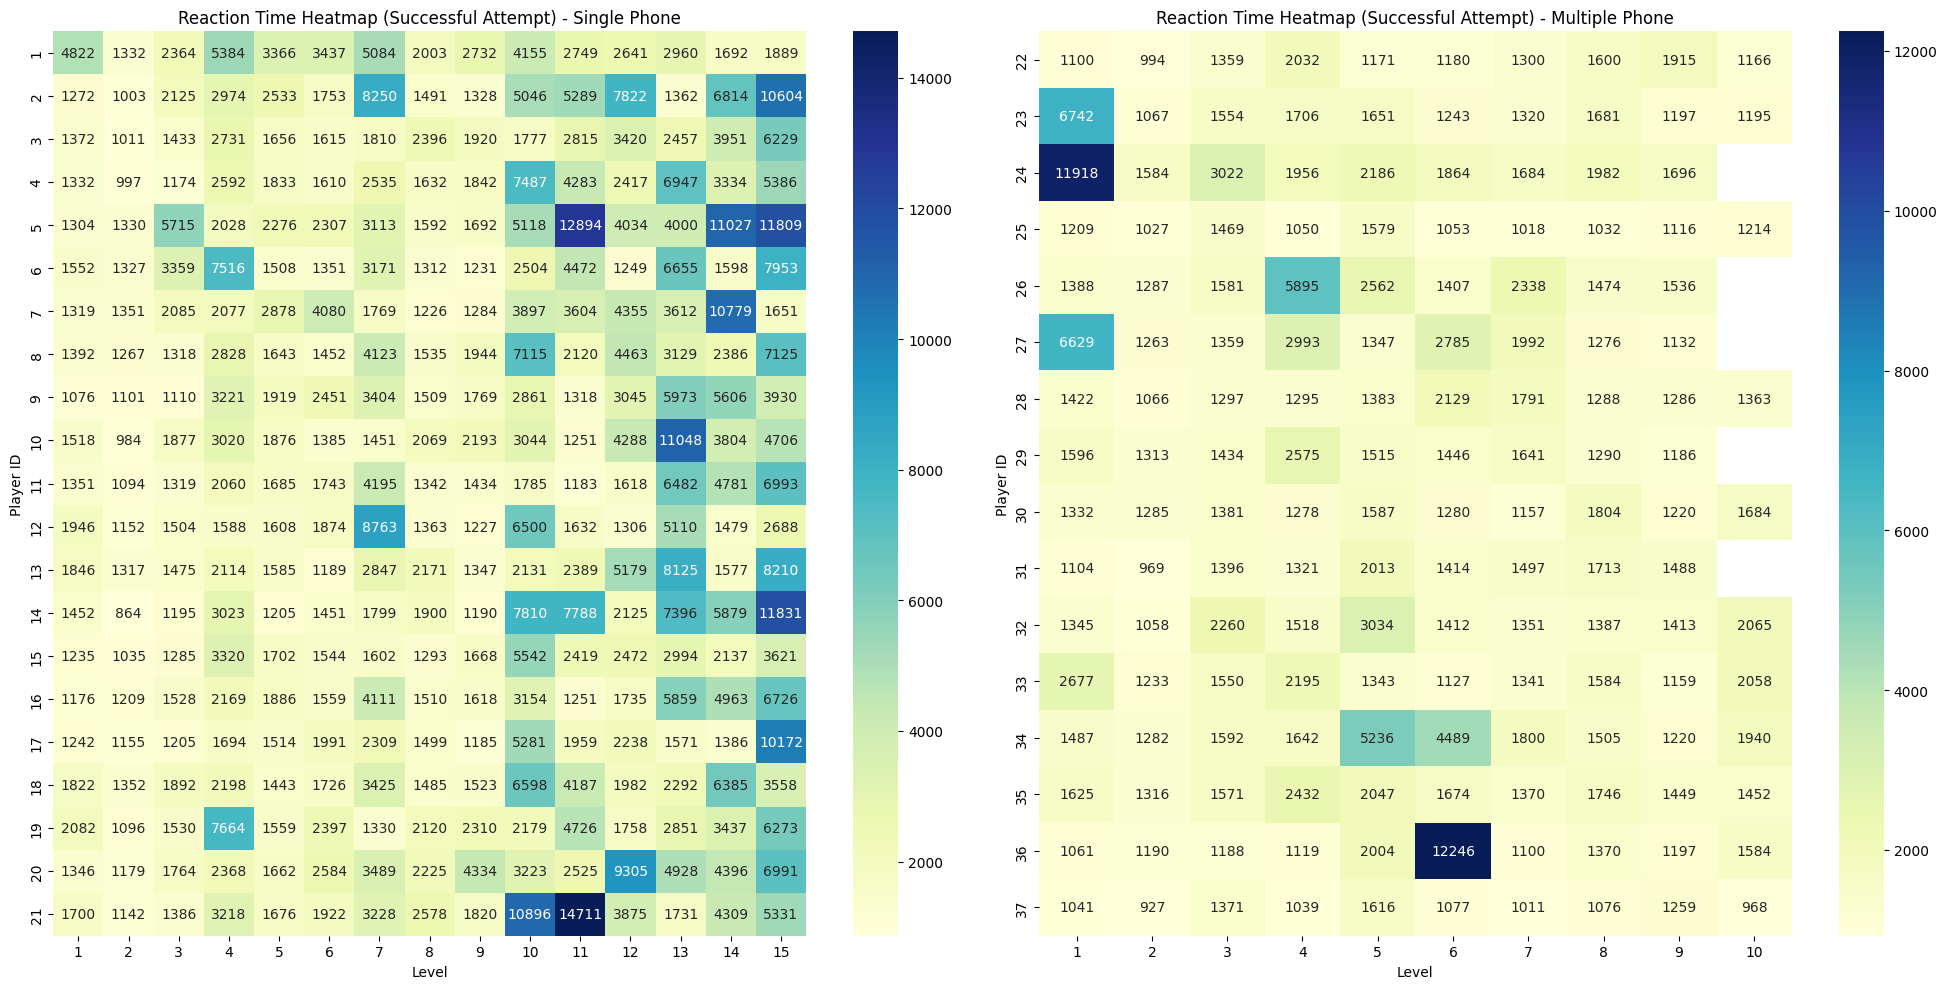

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------- Load datasets --------
df_single = pd.read_csv("single_phone_combined.csv")
df_multiple = pd.read_csv("multiple_phone_combined.csv")

# -------- Convert Timestamp --------
df_single["Timestamp"] = pd.to_datetime(df_single["Timestamp"])
df_multiple["Timestamp"] = pd.to_datetime(df_multiple["Timestamp"])

# -------- Keep only successful attempts --------
df_single_success = df_single[df_single["Completed"] == True]
df_multiple_success = df_multiple[df_multiple["Completed"] == True]

# -------- Sort attempts --------
df_single_success = df_single_success.sort_values(by=["PlayerID", "Level", "Timestamp"])
df_multiple_success = df_multiple_success.sort_values(by=["PlayerID", "Level", "Timestamp"])

# -------- Keep first successful attempt per player per level --------
df_single_success = df_single_success.groupby(["PlayerID", "Level"], as_index=False).first()
df_multiple_success = df_multiple_success.groupby(["PlayerID", "Level"], as_index=False).first()

# -------- Create pivot tables --------
heat_single = df_single_success.pivot(
    index="PlayerID",
    columns="Level",
    values="InitialResponseTime(ms)"
)

heat_multiple = df_multiple_success.pivot(
    index="PlayerID",
    columns="Level",
    values="InitialResponseTime(ms)"
)

# -------- Create side-by-side plots --------
fig, axes = plt.subplots(1, 2, figsize=(20,10))

# ---- Single Target Heatmap ----
sns.heatmap(
    heat_single,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    ax=axes[0]
)

axes[0].set_title("Reaction Time Heatmap (Successful Attempt) - Single Phone")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Player ID")

# ---- Multiple Target Heatmap ----
sns.heatmap(
    heat_multiple,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    ax=axes[1]
)

axes[1].set_title("Reaction Time Heatmap (Successful Attempt) - Multiple Phone")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Player ID")

plt.tight_layout()
plt.show()